### import libraries

In [42]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil


notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

In [43]:
tpad = 1000
xpad = 64
ypad = 64

### Spectrum for regular SASE pulse

In [44]:
energies = [0.1, 1, 10, 40]

norm =  0.9999508432645734
number of seed photons = 3.1e+10
norm =  0.9999508432645734
number of seed photons = 3.1e+10


(0.0, 0.5)

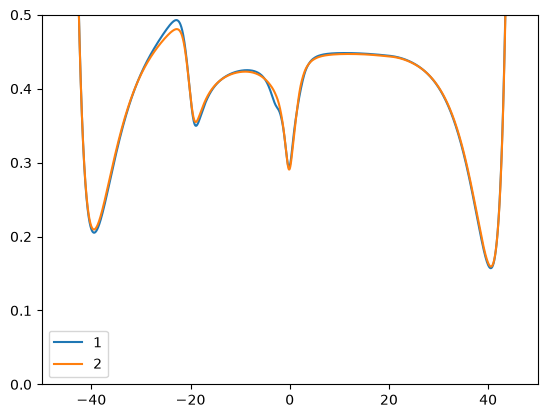

In [45]:
X = XLO_sim(base_directory + '/config/base/Cu-seed-double-satellite-baseline.yaml')
X.random_seed = 42
X.keep_z_history = False
seed_field = tools.Gaussian_pulse_aniso_seed(X)
X.configure(seed_field)
X.run_3D()

womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

plt.plot(womega_ar, I_int_thy_w_last / I_int_thy_w_0, label="1")

X = XLO_sim(base_directory + '/config/base/Cu-seed-satellite-eii.yaml')
X.random_seed = 42
X.keep_z_history = False
seed_field = tools.Gaussian_pulse_aniso_seed(X)
X.configure(seed_field)
X.run_3D()

womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

plt.plot(womega_ar, I_int_thy_w_last / I_int_thy_w_0, label="2")

plt.legend()

plt.xlim(-50, 50)
plt.ylim(0, 0.5)

norm =  0.9999508432645734
number of seed photons = 3.1e+10
norm =  0.9999508432645734
number of seed photons = 3.1e+10


(0.0, 0.5)

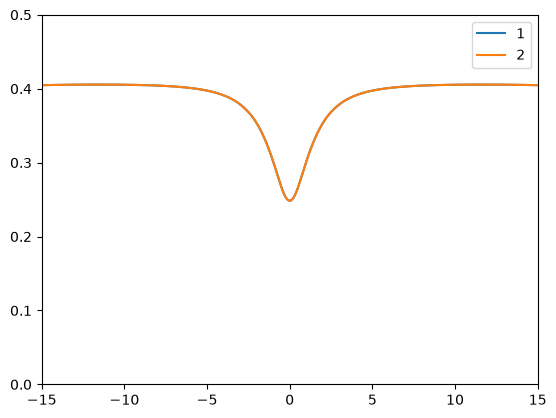

In [14]:

X = XLO_sim(base_directory + '/config/base/Cu-seed.yaml')
X.random_seed = 42
seed_field = tools.Gaussian_pulse_aniso_seed(X)
X.configure(seed_field)
X.run_3D()

womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

plt.plot(womega_ar, I_int_thy_w_last / I_int_thy_w_0, label="1")

X = XLO_sim(base_directory + '/config/base/Cu-seed.yaml')
X.random_seed = 42
X.keep_z_history = False
seed_field = tools.Gaussian_pulse_aniso_seed(X)
X.configure(seed_field)
X.run_3D()

womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

plt.plot(womega_ar, I_int_thy_w_last / I_int_thy_w_0, label="2")

plt.legend()

plt.xlim(-15, 15)
plt.ylim(0, 0.5)

norm =  0.9999508432645734
number of seed photons = 7.8e+07
norm =  0.9999508432645734
number of seed photons = 7.8e+07
norm =  0.9999508432645734
number of seed photons = 7.8e+08
norm =  0.9999508432645734
number of seed photons = 7.8e+08
norm =  0.9999508432645734
number of seed photons = 7.8e+09


KeyboardInterrupt: 

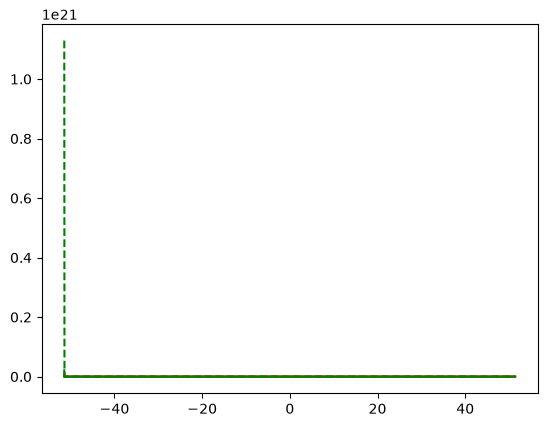

In [15]:
colors = ["r", "g", "b", "y"]

for i, E in enumerate(energies):
    X = XLO_sim(base_directory + '/config/base/Cu-seed.yaml')
    X.random_seed = 42
    X.E_seed_uJ = E
    seed_field = tools.Gaussian_pulse_aniso_seed(X)
    X.configure(seed_field)
    X.run_3D()

    womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
    womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

    plt.plot(womega_ar, I_int_thy_w_last / I_int_thy_w_0, 
             color=colors[i], label=f"6 level at {E} uJ")

    X = XLO_sim(base_directory + '/config/base/Cu-seed-2-level.yaml')
    X.random_seed = 42
    X.E_seed_uJ = E
    seed_field = tools.Gaussian_pulse_aniso_seed(X)
    X.configure(seed_field)
    X.run_3D()

    womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
    womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

    plt.plot(womega_ar, I_int_thy_w_last / I_int_thy_w_0, 
             color=colors[i], label=f"2 level at {E} uJ", linestyle="--")


plt.legend()

plt.xlim(-15, 15)
plt.ylim(0, 0.5)

In [ ]:
X = XLO_sim(base_directory + '/config/base/Cu-seed-SASE.yaml')
X.random_seed = 42
seed_field = tools.Ocelot_SASE_seed_pstxy(X)
X.configure(seed_field)
X.run_3D()

KeyboardInterrupt: 

In [ ]:
womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)


In [ ]:
P_pstxyz = np.array([ np.einsum('ijs,jitxyz->stxyz', X.Tijs_minus, X.rho_ijtxyz) , np.einsum('ijtxyz,jis->stxyz', X.rho_ijtxyz, X.Tijs_plus) ])

I_t_0 = np.einsum('stxy,stxy->t', X.Omega_pstxyz[0, :, :, :, :, 0], X.Omega_pstxyz[1, :, :, :, :, 0])
I_t_last = np.einsum('stxy,stxy->t', X.Omega_pstxyz[0, :, :, :, :, -1], X.Omega_pstxyz[1, :, :, :, :, -1])
rho_ee_t_last = np.einsum('ijs, jkt, kis-> t', X.Tijs_minus, X.rho_ijtxyz[:,:,:,int(X.xgrid/2),int(X.ygrid/2),-1], X.Tijs_plus, optimize=True)
rho_gg_t_last = np.einsum('ijs, jkt, kis-> t', X.Tijs_plus, X.rho_ijtxyz[:,:,:,int(X.xgrid/2),int(X.ygrid/2),-1], X.Tijs_minus, optimize=True)
rho_eg_t_last = P_pstxyz[0,0,:,int(X.xgrid/2),int(X.ygrid/2),-1]
rho_ground_t_last = X.rho_ground_txyz[:,int(X.xgrid/2),int(X.ygrid/2),-1]
t_axis = X.t

date_string = np.datetime_as_string(np.datetime64('now'))
np.savez_compressed(
    "test.npz",
    womega_ar=womega_ar,
    I_int_thy_w_0=I_int_thy_w_0,
    I_int_thy_w_last=I_int_thy_w_last,
    I_t_0=I_t_0,
    I_t_last=I_t_last,
    rho_ee_t_last=rho_ee_t_last,
    rho_gg_t_last=rho_gg_t_last,
    rho_eg_t_last=rho_eg_t_last,
    rho_ground_t_last=rho_ground_t_last,
    t_axis=t_axis
)

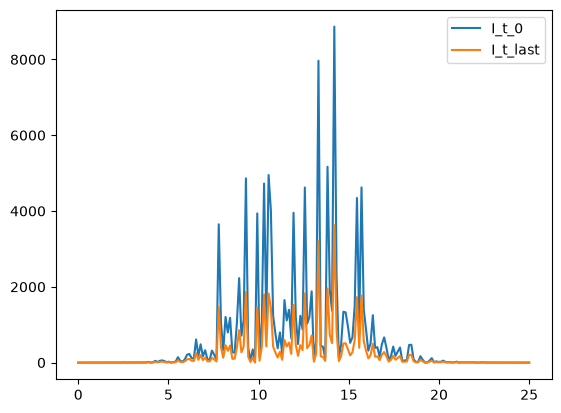

In [ ]:
plt.plot(t_axis, I_t_0, label='I_t_0')
plt.plot(t_axis, I_t_last, label='I_t_last')
plt.legend()

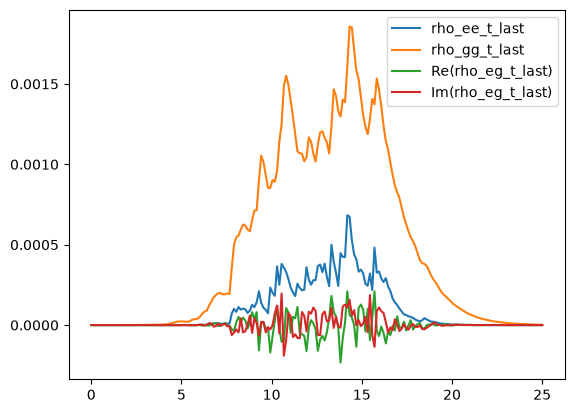

In [ ]:
plt.plot(t_axis, rho_ee_t_last, label='rho_ee_t_last')
plt.plot(t_axis, rho_gg_t_last, label='rho_gg_t_last')
plt.plot(t_axis, np.real(rho_eg_t_last), label='Re(rho_eg_t_last)')
plt.plot(t_axis, np.imag(rho_eg_t_last), label='Im(rho_eg_t_last)')
plt.legend()

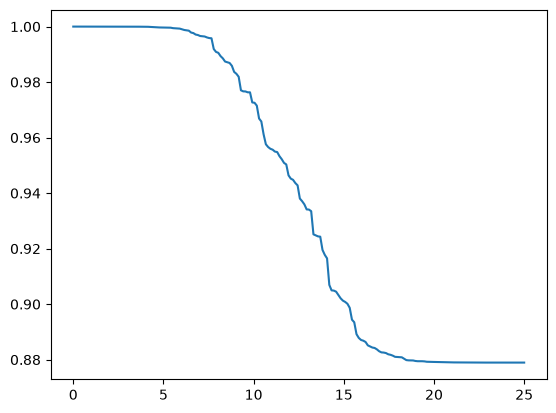

In [ ]:
plt.plot(t_axis, rho_ground_t_last, label='rho_ground_t_last')

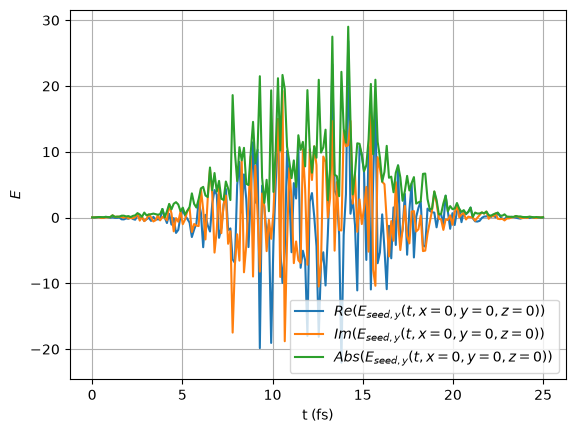

In [ ]:
Omega_pstxy = tools.circular_to_linear(X, X.Omega_pstxyz[:,:,:,:,:,0])
Omega_t   = Omega_pstxy[0,1,:,int(X.xgrid/2),int(X.ygrid/2)]

plt.plot(X.t, np.real(Omega_t), label = r'$Re(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(X.t, np.imag(Omega_t), label = r'$Im(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(X.t, np.abs(Omega_t), label = r'$Abs(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.xlabel('t (fs)')
plt.ylabel(r'$E$')
plt.grid(True)
plt.legend()
plt.show()

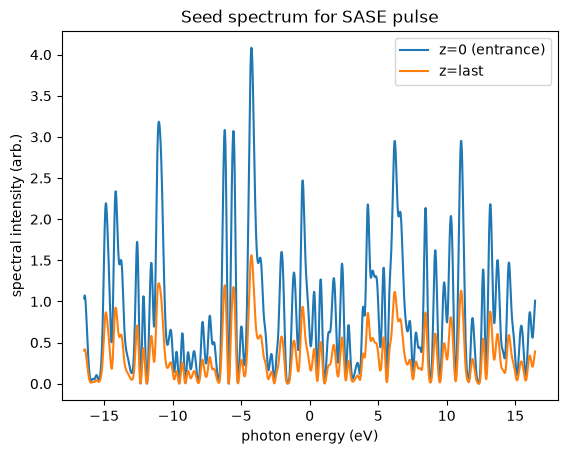

In [ ]:
womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

plt.figure()
plt.plot(womega_ar, I_int_thy_w_0, label='z=0 (entrance)')
plt.plot(womega_ar, I_int_thy_w_last, label='z=last')
# plt.axvline(X.hwKalpha1N, color='gray', ls='--', lw=1, label=f'Cu K$\\alpha$1 = {X.hwKalpha1N:.2f} eV')
plt.xlabel('photon energy (eV)')
plt.ylabel('spectral intensity (arb.)')
plt.legend()
plt.title('Seed spectrum for SASE pulse')
plt.show()

### Spectrum for monochromated SASE pulse

In [ ]:
X = XLO_sim(base_directory + '/config/base/Cu-seed-mono-SASE.yaml')
X.seed_delay = -10
X.random_seed = 42
X.monochromator_target_energy_eV = 8035
seed_field = tools.Ocelot_SASE_seed_111_dcm_pstxy(X)
X.configure(seed_field)
X.run_3D()


KeyboardInterrupt: 

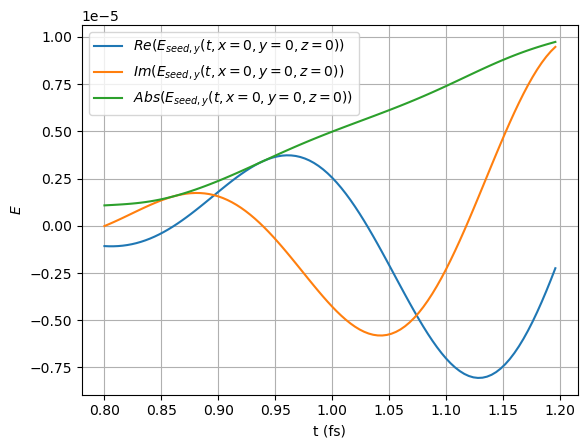

In [ ]:

Omega_pstxy = tools.circular_to_linear(X, X.Omega_pstxyz[:,:,:,:,:,0])
Omega_t   = Omega_pstxy[0,1,:,int(X.xgrid/2),int(X.ygrid/2)]

t_slice = X.t[200:300]
Omega_slice = Omega_t[200:300]

plt.plot(t_slice, np.real(Omega_slice), label = r'$Re(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(t_slice, np.imag(Omega_slice), label = r'$Im(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.plot(t_slice, np.abs(Omega_slice), label = r'$Abs(E_{seed,y}(t,x=0,y=0,z=0))$')
plt.xlabel('t (fs)')
plt.ylabel(r'$E$')
plt.grid(True)
plt.legend()
plt.show()

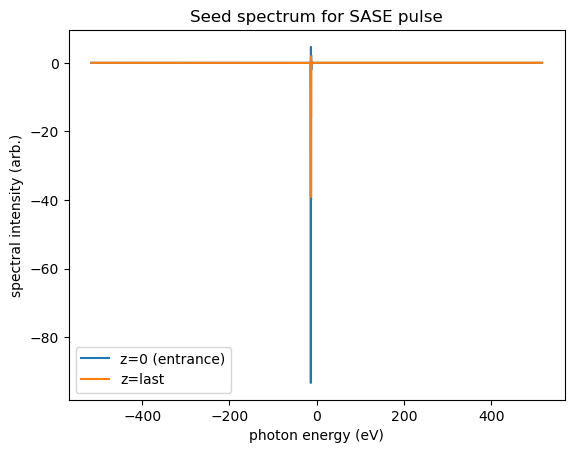

In [ ]:
womega_ar, I_int_thy_w_0, I_thy0_w_0 = tools.SF_spectrum_w(X, 0, ypad, tpad)
womega_ar, I_int_thy_w_last, I_thy0_w_last = tools.SF_spectrum_w(X, -1, ypad, tpad)

plt.figure()
plt.plot(womega_ar, I_int_thy_w_0, label='z=0 (entrance)')
plt.plot(womega_ar, I_int_thy_w_last, label='z=last')
plt.xlabel('photon energy (eV)')
plt.ylabel('spectral intensity (arb.)')
plt.legend()
plt.title('Seed spectrum for SASE pulse')
plt.show()